# КЭЭ эверсионная - Бинарная классификация

## Описание задачи

Пациенты с гемодинамически значимым стенозом внутренней сонной артерии (ВСА) являются кандидатами на выполнение каротидной ангиопластики со каротидной эндартерэктомией (КЭЭ) – эндоваскулярного вмешательства, направленного на восстановление просвета сосуда. Несмотря на меньшую инвазивность по сравнению с каротидной ангиопластикой со стентированием (КАС), КЭЭ сопряжена с риском периоперационных осложнений, включая ишемический инсульт, транзиторную ишемическую атаку (ТИА), гиперперфузионный синдром, тромбоз стента, острый инфаркт миокарда, гематому в месте доступа и острую почечную недостаточность.

Частота этих событий относительно невысока, однако их клиническая значимость диктует необходимость индивидуальной предоперационной оценки риска. Для хирурга принципиально важно располагать инструментом, позволяющим на основе рутинно собираемых анамнестических и клинико-инструментальных данных прогнозировать как сам факт возникновения осложнения, так и его вероятную степень тяжести.

В силу секретности медицинских данных, исходный датасет прикрепляться не будет, поэтому результаты воспроизвести не удасться.

В рамках настоящего ноутбука разрабатывается модель машинного обучения для пациентов, которым планируется КЭЭ эверсионная - один из видов КЭЭ. Модель предназначена для бинарной классификации на следующие классы: отсутствие любого осложнения (0) и наличие осложнения любых осложнений (1).

Исходные данные характеризуются значительным дисбалансом в пользу негативных исходов (осложнения отсутствуют). Применение стандартных классификаторов без учёта дисбаланса приводит к тривиальному решению – предсказанию класса «0» с высокой accuracy, не имеющему клинической ценности.

Для компенсации дисбаланса в экспериментах используются следующие подходы:
1. SMOTE (Synthetic Minority Over-sampling Technique) – генерация синтетических примеров миноритарного класса;
2. class_weight – назначение весов, обратно пропорциональных частоте классов, непосредственно в функции потерь модели.

Исходное признаковое пространство включает 17 переменных:
1. Возраст пациента – числовой тип данных;
2. Пол пациента – категориальный тип данных («м» - мужской, «ж» - женский);
3. Степень стеноза внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49);
4. Степень стеноза контралатеральной внутренней сонной артерии (в %) – категориальный тип данных (100, 90-99, 70-89, 50-69, 0-49, с/п КЭЭ, с/п ТБА);
5. Кальциноз бифуркации общей сонной артерии (степень) – категориальный тип данных (0 – нет, 1 – невыраженный (вкрапления), 2 – циркулярный);
6. Патологическая извитость внутренней сонной артерии – категориальный тип данных (0 – нет 1 – да);
7. Симптомность стеноза внутренней сонной артерии - категориальный тип данных (0 – нет 1 – да);
8. Хроническая сосудисто-мозговая недостаточность (степень) - категориальный тип данных (0, 1, 2, 3, 4);
9. Стенокардия ФК (функциональный класс) - категориальный тип данных (0, 1, 2, 3, 4);
10. Перенесенный инфаркт миокарда - категориальный тип данных (0 – нет 1 – да);
11. Нарушения ритма сердца – категориальный тип данных (0 -нет 1 - да);
12. Хроническая сердечная недостаточность (стадия) – категориальный тип данных (0 – нет, 1, 2 а, 2 б, 3);
13. Функциональный класс по NYHA – (0 – нет 1 - I ФК 2 - II ФК 3 - III ФК 4 - IV ФК);
14. Сахарный диабет – категориальный тип данных (0 – нет 1 – да);
15. Хроническая обструктивная болезнь легких (стадия) – категориальный тип данных (0 – нет 1 – 1 степень 2 – 2 степень 3 – 3 степень);
16. Наличие ОНМК в анамнезе - категориальный тип данных (0 – нет 1 – однократно 2 – повторные);
17. Время окклюзии внутренней сонной артерии (в минутах) – числовой тип данных. Данный параметр характерен только для видов КЭЭ.

Для повышения обобщающей способности моделей исследуется влияние трёх методов уменьшения размерности и отбора признаков:
1. PCA (Principal Component Analysis) – линейное преобразование, сохраняющее максимальную дисперсию данных (число компонент выбирается по критерию 95% объяснённой дисперсии).
2. LDA (Linear Discriminant Analysis) – проекция на подпространство, максимизирующее разделимость классов (для бинарной задачи – на одну ось).
3. SBS (Sequential Backward Selection) – жадный алгоритм исключения признаков, оценивающий качество модели (ROC-AUC) на кросс-валидации после каждого удаления.

Каждый из этих методов применяется к одним и тем же исходным данным независимо, с возвратом к исходной матрице признаков перед каждым преобразованием. Такая схема позволяет корректно сравнить их влияние на итоговые метрики.

Для каждого варианта предобработки обучаются следующие классификаторы:
1. Логистическая регрессия (Logistic Regression);
2. Алгоритм k-ближайших соседей (K-nearst Neighbours);
3. Метод опорных векторов (SVM);
4. Случайный лес (Random Forest);
5. AdaBoost;
6. XGBoost;
7. Многослойный персептрон (MLP).

Оценка качества производится на отложенной тестовой выборке (30% данных для первых 6 моделей и 15% для MLP) с использованием метрик: accuracy, precision, recall, F1-score (macro и weighted), ROC-AUC, MCC (Matthews correlation coefficient).

Подбор гиперпараметров осуществлялся с помощью двух алгоритмов алгоритмов - GridSearch и HalvingGridSearch. В основном использовался первый, второй применялся только для некоторых моделей ансамблей и SVM, когда вычисления проходили крайне долго

В качестве подхода способа обучения моделей классического машинного обучения рассматривались стратифицированная кросс-валидация с 5К-фолдами с разбиением на обучающую и тестовую выборки в соотношении 70:30 соответственно. Для обучения нейронных сетей использовалась стандартное разбиение на обучающую, валидационную и тестовую выборки с разбиением в соотношении 70:15:15 вместе с созданием искусственных синтетических примеров.

## Импортирование необходимых библиотек и объявление вспомогательных классов и функций

Здесь импортируются все необходимые библиотеки для обучения моделей машинного обучения и обработки данных, а также вводятся вспомогательные функции

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, validation_curve, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, make_scorer, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.base import clone
from skorch import NeuralNetClassifier
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline
from collections import Counter
from numpy import interp
from tabulate import tabulate
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.model_selection import HalvingGridSearchCV

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
import xgboost as xgb
from scikeras.wrappers import KerasClassifier
from keras import models, layers, initializers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [4]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle
import json
import joblib

In [5]:
class SBS:
    """Реализация алгоритма SBS"""

    def __init__(self, estimator, k_features, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    
    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        
        X_train, X_test, y_train, y_test = \
            train_test_split(X, y, test_size = self.test_size, random_state = self.random_state)
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]
        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_,  r=dim-1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p) 
                scores.append(score) 
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score

In [6]:
def the_best_features(estimator, k_features, scoring='accuracy', X_train=None, y_train=None):
    """Визуализация точности модели для модели с признаками отобранными SBS с изменением количества"""
    
    if (X_train is None or y_train is None):
        print('Данные о выборке обучающей неполные')
        return None
    
    sbs = SBS(estimator, k_features=k_features, scoring=scoring)
    sbs.fit(X_train, y_train)
    k_feat = [len(k) for k in sbs.subsets_]
    plt.plot(k_feat, sbs.scores_, marker='o')
    plt.ylim([0.0, 1.02])
    plt.ylabel('Точность')
    plt.xlabel('Количество признаков')
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    return sbs

In [7]:
def rename_columns_categorical(df):
    """Переименование колонок для категореальных признаков после применения onehotencoder"""
    
    categorical_features = list(df.columns)[:-2]
    
    for i in range (len(categorical_features)):
         categorical_features[i]= categorical_features[i].replace("onehotencoder__", "")  
    return categorical_features 

In [8]:
def grid_search_for_model(estimator, param_grid, X_train, y_train, cv=20):
    """Подбор гиперпараметров с помощью GridSearch"""
    
    gs = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='recall', cv=cv, refit=True , verbose=1, n_jobs=1)
    gs = gs.fit(X_train, y_train)
    print(gs.best_score_)
    print(gs.best_params_)

In [9]:
def halving_search_for_model(estimator, param_grid, X_train, y_train, cv=5, n_iter=30):
    """Подбор гиперпараметров с помощью HalvingGridSearch"""
    
    hgs = HalvingGridSearchCV(estimator, param_grid=param_grid, min_resources=50, scoring='recall', cv=cv,
                               verbose=1,n_jobs=-1, random_state=1)
    hgs = hgs.fit(X_train, y_train)
    print(hgs.best_score_)
    print(hgs.best_params_)

In [10]:
def random_search_for_model(estimator, param_grid, X_train, y_train, cv=5, n_iter=30):
    """Подбор гиперпараметров с помощью RandomizedSearch"""
    
    rs = RandomizedSearchCV(estimator, param_distributions=param_grid, n_iter=n_iter, scoring='recall', cv=cv,
                               verbose=1,n_jobs=-1, random_state=1)
    rs = rs.fit(X_train, y_train)
    print(rs.best_score_)
    print(rs.best_params_)

In [11]:
def select_index_features(sbs, index, X_train, X_test): 
    """Выбор признаков SBS к обучеющей и тестовой выборкам"""
    
    k = list(sbs.subsets_[index])
    
    if hasattr(X_train, 'iloc'):
        X_train_selected = X_train.iloc[:, k].copy()
        X_test_selected = X_test.iloc[:, k].copy()
    else:
        X_train_selected = X_train[:, k].copy()
        X_test_selected = X_test[:, k].copy()
    
    return X_train_selected, X_test_selected 

In [12]:
def model_training(estimator, X_train, y_train, n_splits=20, cv=5):
    """Обучение моделей классического машинного обучения"""
    
    kfold = StratifiedKFold(n_splits=n_splits).split(X_train, y_train)
    scores = []
    
    if hasattr(X_train, 'iloc'):
        for k, (train, test) in enumerate(kfold):
            estimator.fit(X_train.iloc[train], y_train.iloc[train] if hasattr(y_train, 'iloc') else y_train[train])
            score = estimator.score(X_train.iloc[test], y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test])
            scores.append(score)
            print(f'Выборка: {k+1:02d}, '
                  f'Распр. кл.: {np.bincount(y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test])}, '
                  f'Точн.: {score:.3f}')
    else:
        for k, (train, test) in enumerate(kfold):
            estimator.fit(X_train[train], y_train[train])
            score = estimator.score(X_train[test], y_train[test])
            scores.append(score)
            print(f'Выборка: {k+1:02d}, '
                  f'Распр. кл.: {np.bincount(y_train[test])}, '
                  f'Точн.: {score:.3f}')
    
    final_scores = cross_val_score(estimator=estimator, X=X_train, y=y_train, cv=cv, n_jobs=1)
    print(f'Точность по CV: {np.mean(final_scores):.3f} '
          f'+/- {np.std(final_scores):.3f}')
    
    return estimator

In [13]:
def calculate_metrics(y_true, y_pred, metrics, average_methods):
    """Вычисление метрик"""
    
    metrics_dict = {}
    
    for metric in metrics:
        if metric == 'accuracy':
            metrics_dict['accuracy'] = accuracy_score(y_true, y_pred)
        
        elif metric in ['precision', 'recall', 'f1']:
            for avg in average_methods:
                metric_func = {
                    'precision': precision_score,
                    'recall': recall_score,
                    'f1': f1_score
                }[metric]
                try:
                    metrics_dict[f'{metric}_{avg}'] = metric_func(y_true, y_pred, average=avg)
                except:
                    metrics_dict[f'{metric}_{avg}'] = np.nan
        
        elif metric == 'mcc':
            try:
                metrics_dict['mcc'] = matthews_corrcoef(y_true, y_pred)
            except:
                metrics_dict['mcc'] = np.nan
    
    return metrics_dict

In [14]:
def print_results_table(results, metrics, average_methods):
    """Создание таблицы с посчитанными значениями метрик"""
    
    table_data = []
    headers = ['Dataset']
    
    for metric in metrics:
        if metric == 'accuracy':
            headers.append('Accuracy')
        elif metric == 'mcc':
            headers.append('MCC')
        else:
            for avg in average_methods:
                headers.append(f'{metric.capitalize()} ({avg})')
    
    for dataset, metrics_dict in results.items():
        row = [dataset]
        for metric in metrics:
            if metric == 'accuracy':
                row.append(f"{metrics_dict.get('accuracy', 0):.3f}")
            elif metric == 'mcc':
                row.append(f"{metrics_dict.get('mcc', 0):.3f}")
            else:
                for avg in average_methods:
                    key = f'{metric}_{avg}'
                    row.append(f"{metrics_dict.get(key, 0):.3f}")
        table_data.append(row)
    
    print(tabulate(table_data, headers=headers, tablefmt='grid', stralign='center'))

In [15]:
def evalute_model(estimator, data, metrics=None, average_methods=['micro', 'macro']):
    """Вывод посчитанных метрик и визуализация матрицы ошибок"""
    
    if metrics is None:
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
    
    results = {}
    
    fig, axes = plt.subplots(1, len(data), figsize=(5*len(data), 4))
    if len(data) == 1:
        axes = [axes]
    
    for idx, (name, (X, y)) in enumerate(data.items()):
        y_pred = np.round(estimator.predict(X))
        
        confmat = confusion_matrix(y_true=y, y_pred=y_pred)
        axes[idx].matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
        for i in range(confmat.shape[0]):
            for j in range(confmat.shape[1]):
                axes[idx].text(x=j, y=i, s=confmat[i, j], va='center', ha='center', fontsize=12)
        
        axes[idx].xaxis.set_ticks_position('bottom')
        axes[idx].set_xlabel('Предсказанная метка')
        axes[idx].set_ylabel('Истинная метка')
        axes[idx].set_title(f'Матрица ошибок - {name}')
        
        results[name] = calculate_metrics(y, y_pred, metrics, average_methods)
    
    plt.tight_layout()
    plt.show()
    
    print_results_table(results, metrics, average_methods)
    
    return results

In [16]:
def ROC_curve(estimator, X_train, X_test, y_train, y_test, n_splits=20):
    """Построение графиков ROC-кривых"""
    
    cv = list(StratifiedKFold(n_splits=n_splits).split(X_train, y_train))
    
    plt.figure(figsize=(7, 5))
    mean_tpr = 0.0
    mean_fpr = np.linspace(0, 1, 100)
    
    use_pandas = hasattr(X_train, 'iloc')
    
    for i, (train, test) in enumerate(cv):
        if use_pandas:
            X_train_fold = X_train.iloc[train]
            y_train_fold = y_train.iloc[train] if hasattr(y_train, 'iloc') else y_train[train]
            X_val_fold = X_train.iloc[test]
            y_val_fold = y_train.iloc[test] if hasattr(y_train, 'iloc') else y_train[test]
        else:
            X_train_fold = X_train[train]
            y_train_fold = y_train[train]
            X_val_fold = X_train[test]
            y_val_fold = y_train[test]
        
        probas = estimator.fit(X_train_fold, y_train_fold).predict_proba(X_val_fold)
        fpr, tpr, _ = roc_curve(y_val_fold, probas[:, 1], pos_label=1)
        
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr[0] = 0.0
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Выборка ROC {i+1} (area={roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='Случайный выбор (area=0.5)')
    plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='black', label='Идеальная производительность (area=1.0)')
    
    mean_tpr /= len(cv)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, 'k--', label=f'Средн. ROC (area = {mean_auc:.2f})', lw=2)
    
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Доля ложноположительных прогнозов')
    plt.ylabel('Доля истинно положительных прогнозов')
    plt.legend(loc='lower right')
    plt.show()

In [17]:
def ROC_curve_for_keras(data, model):
    """Построение графиков ROC-кривых для Keras"""

    for name, (X_data, y_data) in data.items():
        y_prob = model.predict(X_data)
        fpr, tpr, thresholds = roc_curve(y_data, y_prob)
        auc = roc_auc_score(y_data, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curves for Train, Validation, and Test Data')
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
def manual_keras_grid_search(X_train, y_train, param_grid, cv=5):
    """Реализация алгоритма GridSearch для Keras"""
    
    best_score = -1
    best_params = None
    results = []
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    param_combinations = list(ParameterGrid(param_grid))
    
    print(f"Всего комбинаций: {len(param_combinations)}")
    
    for i, params in enumerate(param_combinations):
        print(f"\nКомбинация {i+1}/{len(param_combinations)}: {params}")
        
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
            
            model = Sequential()
            
            model.add(Input(shape=(X_train.shape[1],)))
            
            model.add(Dense(params['hidden_layer_sizes'][0],  
                           activation=params['activation'], 
                           kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
            if params['use_batch_norm']:
                 model.add(BatchNormalization())
             
            if params['dropout_rate'] > 0:
                model.add(Dropout(params['dropout_rate']))
            
            for units in params['hidden_layer_sizes'][1:]:
                model.add(Dense(units, activation=params['activation'], 
                                kernel_regularizer=l1_l2(l1=params['l1_reg'], l2=params['l2_reg'])))
                if params['use_batch_norm']:
                     model.add(BatchNormalization())
             
                if params['dropout_rate'] > 0:
                    model.add(Dropout(params['dropout_rate']))
            
            model.add(Dense(1, activation='sigmoid'))
            if params['optimizer'] == 'adam':
                optimizer = Adam(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'rmsprop':
                optimizer = RMSprop(learning_rate=params['learning_rate'])
            elif params['optimizer'] == 'sgd':
                optimizer = SGD(learning_rate=params['learning_rate'], momentum=0.9)
            else:
                optimizer = Adam(learning_rate=params['learning_rate'])
            
            model.compile(loss='binary_crossentropy', 
                         optimizer=optimizer,
                         metrics=['accuracy'])
            
            history = model.fit(X_train_fold, y_train_fold,
                              epochs=params['epochs'],
                              batch_size=params['batch_size'],
                              verbose=0,
                              validation_data=(X_val_fold, y_val_fold))
            
            y_pred = (model.predict(X_val_fold) > 0.5).astype(int)
            score = recall_score(y_val_fold, y_pred)
            cv_scores.append(score)
            
            print(f"  Fold {fold+1}: recall = {score:.4f}")
        
        mean_score = np.mean(cv_scores)
        print(f"  Средний recall: {mean_score:.4f}")
        
        results.append({
            'params': params,
            'score': mean_score
        })
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print("5 лучших результатов:")
    for i, res in enumerate(results[:5]):
        print(f"{i+1}. Score: {res['score']:.4f}, Params: {res['params']}")
    
    print(f"Лучший результат: {best_score:.4f}")
    print(f"Лучшие параметры: {best_params}")
    
    return best_score, best_params, results

In [19]:
f1_scorer_macro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro')
f1_scorer_micro = lambda y_true, y_pred: f1_score(y_true, y_pred, average='micro')
pre_scorer_macro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='macro')
pre_scorer_micro = lambda y_true, y_pred: precision_score(y_true, y_pred, average='micro')
rec_scorer_macro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='macro')
rec_scorer_micro = lambda y_true, y_pred: recall_score(y_true, y_pred, average='micro')
mcc_scorer_micro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='micro')
mcc_scorer_macro = lambda y_true, y_pred: matthews_corrcoef(y_true, y_pred, average='macro')

## Загрузка и предварительная обработка набора данных

Здесь происходит загрузка имеющегося набора данных, удаление лишних столбцов, предобработка данных (кодирование категореальных переменных и стандартизация числовых признаков)

In [20]:
data_kee_evers = pd.read_excel('Data_Multiclass.xlsx', sheet_name='KEE - evers')

In [21]:
label_cols = ['onmk', 'tia', 'thrombosis', 'oim', 'pneumonia', 
              'post_puncture_hematoma', 'cranial_nerve_damage', 'bleeding']
data_kee_evers = data_kee_evers.drop(columns=label_cols)

In [22]:
data_kee_evers = data_kee_evers.drop(columns=['п/п','type_of_surgical_intervention', 'type_of_surgical_intervention', 'type_of_CEE'])

In [23]:
categorical_features = ['gender', 'degree_of_stenosis_of_the_internal_carotid_artery',	
                        'stenosis_degree_of_the_contralateral_internal_carotid_artery',	
                        'calcinosis', 'pivsa', 'symptoms_of_internal_carotid_artery_stenosis',	
                        'hsmn',	'angina_pectoris_FC', 'pim', 'heart_rhythm_disturbances', 'hsn',	
                        'FC_by_NYHA', 'sd',	'hobl', 'history_of_oncological_cancer']
numeric_features = ['age']

In [24]:
X = data_kee_evers.drop(columns=['complication']).astype(str)
y = data_kee_evers['complication']

In [25]:
X.gender = X.gender.str.strip()
X.gender = X.gender.str.lower()

In [26]:
X.gender.unique()

array(['м', 'ж'], dtype=object)

In [27]:
pd.set_option('display.max_columns', None)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [29]:
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', scaler, numeric_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.fit(X)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test = pd.DataFrame(X_test_transformed, columns=feature_names)

print(X_train)
print(X_test)

joblib.dump(preprocessor, 'preprocessor_kee_classic_final.pkl')

    gender_ж gender_м  \
0        0.0      1.0   
1        0.0      1.0   
2        0.0      1.0   
3        0.0      1.0   
4        1.0      0.0   
..       ...      ...   
827      0.0      1.0   
828      0.0      1.0   
829      0.0      1.0   
830      1.0      0.0   
831      0.0      1.0   

    degree_of_stenosis_of_the_internal_carotid_artery_    70-89  \
0                                                  0.0            
1                                                  0.0            
2                                                  0.0            
3                                                  0.0            
4                                                  0.0            
..                                                 ...            
827                                                0.0            
828                                                0.0            
829                                                0.0            
830                          

['preprocessor_kee_classic_final.pkl']

In [30]:
print(X.columns.tolist())

['gender', 'age', 'degree_of_stenosis_of_the_internal_carotid_artery', 'stenosis_degree_of_the_contralateral_internal_carotid_artery', 'calcinosis', 'pivsa', 'symptoms_of_internal_carotid_artery_stenosis', 'hsmn', 'angina_pectoris_FC', 'pim', 'heart_rhythm_disturbances', 'hsn', 'FC_by_NYHA', 'sd', 'hobl', 'history_of_oncological_cancer', 'occlusion_time']


In [31]:
X

,gender,age,degree_of_stenosis_of_the_internal_carotid_artery,stenosis_degree_of_the_contralateral_internal_carotid_artery,calcinosis,pivsa,symptoms_of_internal_carotid_artery_stenosis,hsmn,angina_pectoris_FC,pim,heart_rhythm_disturbances,hsn,FC_by_NYHA,sd,hobl,history_of_oncological_cancer,occlusion_time
0,м,67,70-89,50-69,0,1,0,1,1,1,0,2 а,2,0,1,0,25
1,м,52,70-89,с/п ТБА,0,0,0,3,0,0,0,1,0,0,0,0,28
2,м,54,50-69,0-49,0,0,1,4,1,1,0,2 а,2,0,0,1,30
3,м,49,90-99,0-49,0,0,1,4,0,0,0,2 а,2,0,0,1,40
4,м,58,70-89,0-49,0,0,0,3,1,1,0,2 а,2,0,0,0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,м,62,50-69,с/п КЭЭ,0,0,0,1,0,0,0,1,2,0,0,0,21
1185,м,63,50-69,с/п КЭЭ,0,0,0,4,0,0,1,1,2,0,0,1,19
1186,ж,72,70-89,с/п КЭЭ,0,0,0,0,0,0,0,1,2,1,0,0,22
1187,ж,72,50-69,с/п КЭЭ,0,1,0,3,2,0,1,1,2,0,0,0,17


In [32]:
X_train

,gender_ж,gender_м,degree_of_stenosis_of_the_internal_carotid_artery_ 70-89,degree_of_stenosis_of_the_internal_carotid_artery_0-49,degree_of_stenosis_of_the_internal_carotid_artery_50-69,degree_of_stenosis_of_the_internal_carotid_artery_70-89,degree_of_stenosis_of_the_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_0-49,stenosis_degree_of_the_contralateral_internal_carotid_artery_100,stenosis_degree_of_the_contralateral_internal_carotid_artery_50-69,stenosis_degree_of_the_contralateral_internal_carotid_artery_70-89,stenosis_degree_of_the_contralateral_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п КЭЭ,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п ТБА,calcinosis_0,calcinosis_1,calcinosis_2,pivsa_0,pivsa_1,symptoms_of_internal_carotid_artery_stenosis_0,symptoms_of_internal_carotid_artery_stenosis_1,hsmn_0,hsmn_1,hsmn_2,hsmn_3,hsmn_4,angina_pectoris_FC_0,angina_pectoris_FC_1,angina_pectoris_FC_2,angina_pectoris_FC_3,pim_0,pim_1,heart_rhythm_disturbances_0,heart_rhythm_disturbances_1,hsn_0,hsn_1,hsn_2 а,hsn_2 б,hsn_3,FC_by_NYHA_0,FC_by_NYHA_1,FC_by_NYHA_2,FC_by_NYHA_3,FC_by_NYHA_4,sd_0,sd_1,hobl_0,hobl_1,hobl_2,hobl_3,history_of_oncological_cancer_0,history_of_oncological_cancer_1,history_of_oncological_cancer_2,age,occlusion_time
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.156367,14
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.272635,24
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.711841,15
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.528457,17
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.20796,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.33199,15
828,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.272635,25
829,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.215722,24
830,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.339752,20


## Уменьшение размерности с помощью линейного дискриминантного анализа и обучение различных типов моделей

In [33]:
lda = LDA(solver= 'svd')

In [34]:
y_train_lda = y_train.values.ravel()
y_test_lda = y_test.values.ravel()
X_train_lda = lda.fit_transform(X_train, y_train_lda)
X_test_lda = lda.transform(X_test)

In [35]:
data = {"Train": (X_train_lda, y_train_lda),
        "Test": (X_test_lda, y_test_lda)}

### Логистическая регрессия

In [68]:
lr = LogisticRegression(random_state=1)
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_grid_lr = [{'C': param_range, 'solver': ['lbfgs'], 'penalty': ['l2'], 'max_iter': [100, 200, 500, 1000, 10000] }, 
             {'C': param_range, 'solver': ['liblinear'], 'penalty': ['l2', 'l1'], 'max_iter': [100, 200, 500, 1000, 10000] }, 
             {'C': param_range, 'solver': ['newton-cg'], 'penalty': ['l2']},
             {'C': param_range, 'solver': ['newton-cholesky'], 'penalty': ['l2'], 'max_iter': [100, 200, 500, 1000, 10000] },
             {'C': param_range, 'solver': ['sag'], 'penalty': ['l2'], 'max_iter': [5000, 10000] },
             {'C': param_range, 'solver': ['saga'], 'penalty': ['elasticnet'], 'max_iter': [5000, 10000], 'l1_ratio': [0.1, 0.2, 0.5, 0.9]},
            {'C': param_range, 'solver': ['saga'], 'penalty': ['l1', 'l2'], 'max_iter': [5000, 10000]}
             ]
grid_search_for_model(lr, param_grid_lr, X_train_lda, y_train_lda)

Fitting 20 folds for each of 210 candidates, totalling 4200 fits
0.3416666666666667
{'C': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [69]:
lr = LogisticRegression(C = 1.0, max_iter= 100, penalty = 'l2', solver = 'lbfgs')
lr1 = model_training(lr, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20) 

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.929
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.951
Точность по CV: 0.960 +/- 0.016


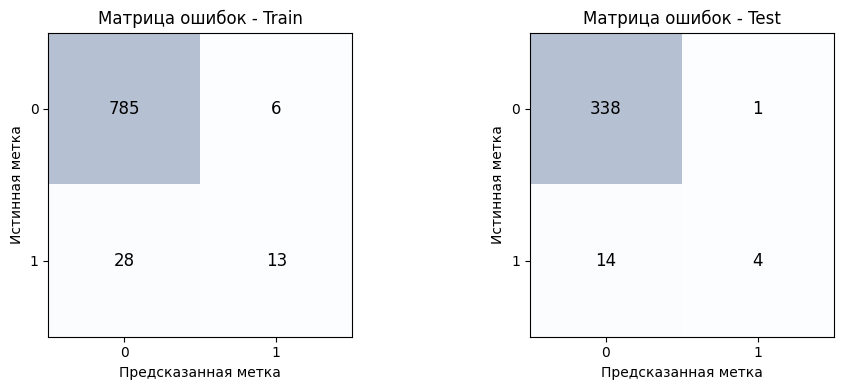

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.959 |               0.959 |               0.825 |            0.959 |            0.655 |        0.959 |        0.706 | 0.448 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.958 |               0.958 |               0.88  |            0.958 |            0.61  |        0.958 |        0.663 | 0.408 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

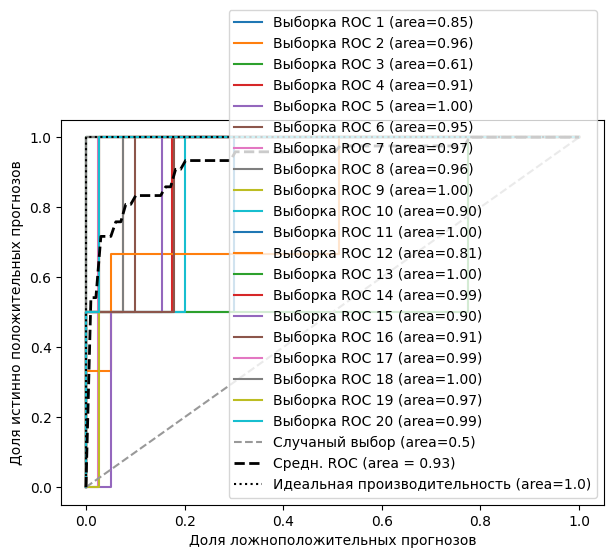

In [70]:
results = evalute_model(lr1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(lr1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

### Алгоритм k-ближайших соседей

In [71]:
knn = KNeighborsClassifier(metric='minkowski')
param_grid_knn = {
    'n_neighbors': list(range(1, 7, 2)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2, 3], 
    'leaf_size': [10, 20, 30, 40, 50]
}
grid_search_for_model(knn, param_grid_knn, X_train_lda, y_train_lda)

Fitting 20 folds for each of 270 candidates, totalling 5400 fits
0.35
{'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}


In [72]:
knn = KNeighborsClassifier(algorithm = 'auto', leaf_size = 10, n_neighbors = 1, p = 1, weights = 'uniform')
knn1 = model_training(knn, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.881
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.829
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.927
Точность по CV: 0.933 +/- 0.033


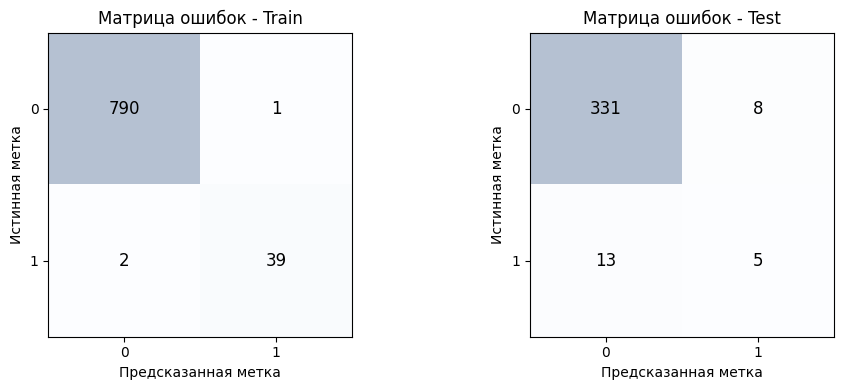

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.996 |               0.996 |               0.986 |            0.996 |            0.975 |        0.996 |        0.981 | 0.961 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.941 |               0.941 |               0.673 |            0.941 |            0.627 |        0.941 |        0.646 | 0.297 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

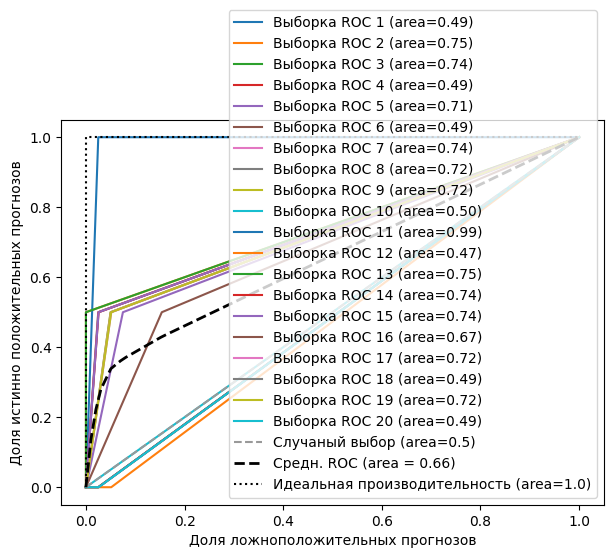

In [73]:
results = evalute_model(knn1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(knn1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

### SVM

In [ ]:
svc = SVC(random_state=1)
param_grid_svc = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'coef0': [0, 1, 2]  
    }
]
grid_search_for_model(svc, param_grid_svc, X_train_lda, y_train_lda)

Fitting 20 folds for each of 128 candidates, totalling 2560 fits


In [ ]:
svc = SVC(random_state=1, C=1, kernel='rbf', gamma=10, probability=True)
svc1 = model_training(svc, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)
results = evalute_model(svc1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(svc1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

### XGBoost

In [74]:
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8, 1.0]
}
xgbm = xgb.XGBClassifier(random_state=1)
grid_search_for_model(xgbm, param_grid_xgb, X_train_lda, y_train_lda)

Fitting 20 folds for each of 16 candidates, totalling 320 fits
0.3833333333333333
{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [75]:
xgbm = xgb.XGBClassifier(n_estimators=100, learning_rate=0.3, 
                         subsample = 0.8, max_depth=3,random_state=1)
xgbm1 = model_training(xgbm, X_train=X_train_lda, y_train=y_train_lda, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 1.000
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 11, Распр. кл.: [40  2], Точн.: 1.000
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.952
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.976
Точность по CV: 0.955 +/- 0.023


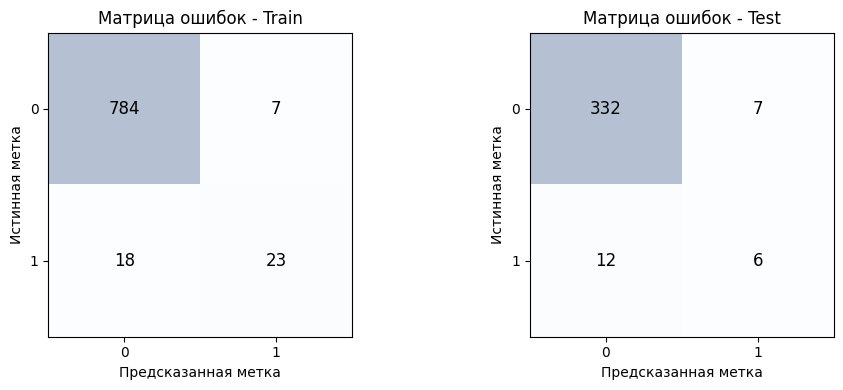

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.97  |               0.97  |               0.872 |            0.97  |            0.776 |        0.97  |        0.816 | 0.641 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.947 |               0.947 |               0.713 |            0.947 |            0.656 |        0.947 |        0.68  | 0.365 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

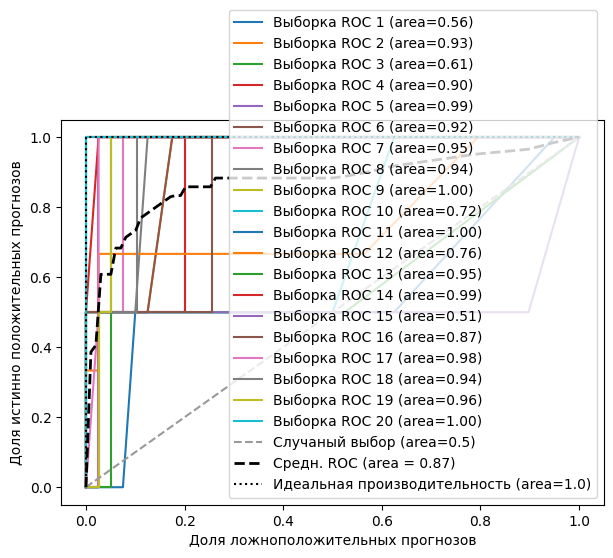

In [76]:
results = evalute_model(xgbm1, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(xgbm1, X_train_lda, X_test_lda, y_train_lda, y_test_lda, n_splits=20)

### MLP

In [77]:
X_val_lda, X_test_lda, y_val_lda, y_test_lda = train_test_split(
    X_test_lda, y_test_lda, test_size=0.5, random_state=42, stratify=y_test_lda
)
smote = SMOTE(random_state=42, sampling_strategy=0.65)
X_train_sample, y_train_sample = smote.fit_resample(X_train_lda, y_train_lda)

In [78]:
param_grid_net = {
    'batch_size': [16, 32],
    'epochs': [30],
    'learning_rate': [0.001],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'elu'],
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'dropout_rate': [0.2],
    'use_batch_norm': [True],
    'l1_reg': [0.001],
    'l2_reg': [0.001]
}

best_score, best_params, all_results = manual_keras_grid_search(
    X_train_lda, y_train_lda, param_grid_net, cv=5
)

Всего комбинаций: 24

Комбинация 1/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer': 'adam', 'use_batch_norm': True}
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
  Fold 1: recall = 0.2500
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
  Fold 2: recall = 0.1429
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
  Fold 3: recall = 0.3750
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
  Fold 4: recall = 0.2500
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
  Fold 5: recall = 0.5000
  Средний recall: 0.3

In [80]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_lda.shape[1], )))

model.add(layers.Dense(64, 
                      activation='elu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(32, 
                      activation='elu',
                      kernel_regularizer=regularizers.l1_l2(0.001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, 
                      activation='elu',
                      kernel_regularizer=regularizers.l1_l2(0.01)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(4, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(2, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=16, validation_data=(X_val_lda, y_val_lda))

Epoch 1/40
82
821m 1/82 ━━━━━━━━━━━━━━━━━━━━ 36:53 27s/step - accuracy: 0.4375 - loss: 2.0877 - precision: 0.1667 - recall: 0.2000
821m 3/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4444 - loss: 2.0444 - precision: 0.1811 - recall: 0.2214  
821m 4/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4505 - loss: 2.0287 - precision: 0.2099 - recall: 0.2530
821m 6/82 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4500 - loss: 2.0091 - precision: 0.2344 - recall: 0.2919
821m 7/82 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4457 - loss: 2.0041 - precision: 0.2373 - recall: 0.3028
821m 9/82 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4438 - loss: 1.9991 - precision: 0.2466 - recall: 0.3263
821m11/82 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4400 - loss: 1.9983 - precision: 0.2541 - recall: 0.3399
821m13/82 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4377 - loss: 1.9952 - precision: 0.2625 - recall: 0.3514
821m16/82 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4369

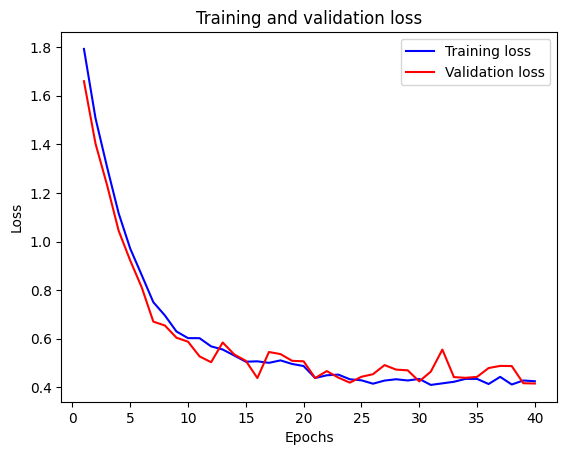

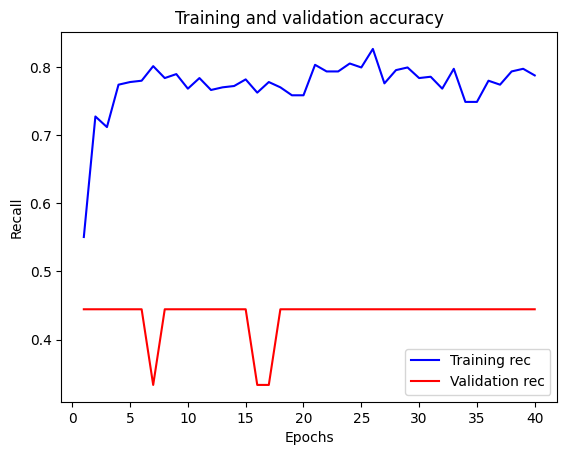

<Figure size 640x480 with 0 Axes>

In [81]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training rec')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [82]:
data = {
            "Train": (X_train_lda, y_train_lda),
            "Validation": (X_val_lda, y_val_lda),
            "Test": (X_test_lda, y_test_lda)
        }

26
261m 1/26 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step
261m15/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


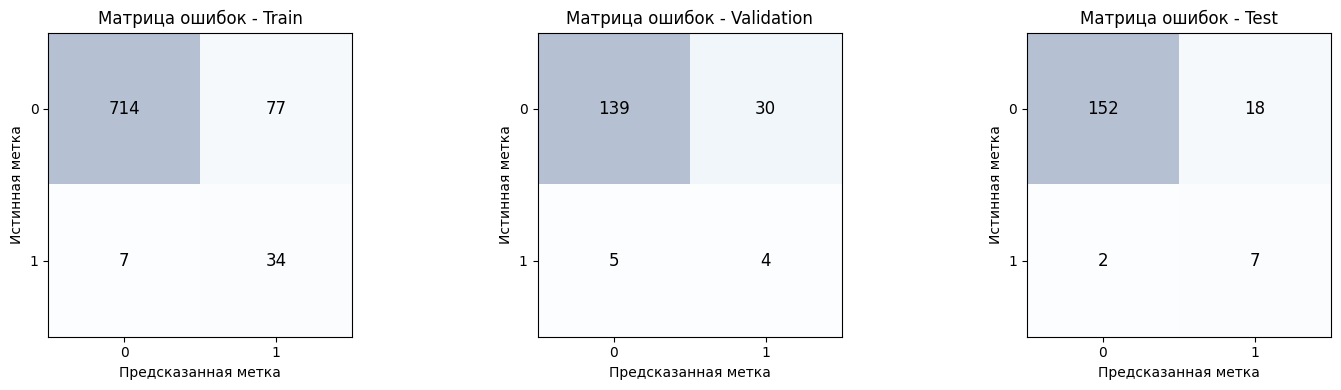

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.899 |               0.899 |               0.648 |            0.899 |            0.866 |        0.899 |        0.696 | 0.466 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.803 |               0.803 |               0.541 |            0.803 |            0.633 |        0.803 |        0.537 | 0.149 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

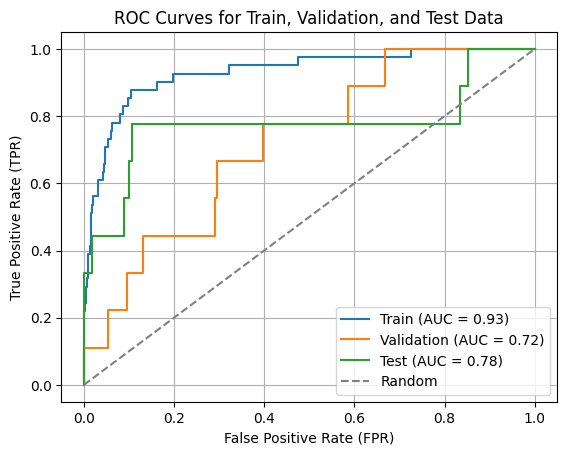

In [83]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [91]:
joblib.dump(lda, 'lda_kee_classic_final1.pkl')
model.save('neural_net_model_kee_evers_lda_final.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_classic_lda_binary_final1.json', 'w') as f:
    json.dump(metadata, f, indent=4)

## Уменьшение размерности с помощью метода главных компонент и обучение различных типов моделей

In [63]:
X_train_reset = X_train.reset_index()
X_test_reset = X_test.reset_index()

In [64]:
y_train_reset = y_train.reset_index()
y_test_reset = y_test.reset_index()

### Логистическая регрессия

In [65]:
y_train_reset = y_train.iloc[:, -1]
y_test_reset = y_test.iloc[:, -1]

In [66]:
X_train_reset =X_train_reset.drop(columns=['index'])
X_test_reset = X_test_reset.drop(columns=['index'])

In [67]:
X_train_reset

,gender_ж,gender_м,degree_of_stenosis_of_the_internal_carotid_artery_ 70-89,degree_of_stenosis_of_the_internal_carotid_artery_0-49,degree_of_stenosis_of_the_internal_carotid_artery_50-69,degree_of_stenosis_of_the_internal_carotid_artery_70-89,degree_of_stenosis_of_the_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_0-49,stenosis_degree_of_the_contralateral_internal_carotid_artery_100,stenosis_degree_of_the_contralateral_internal_carotid_artery_50-69,stenosis_degree_of_the_contralateral_internal_carotid_artery_70-89,stenosis_degree_of_the_contralateral_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п КЭЭ,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п ТБА,calcinosis_0,calcinosis_1,calcinosis_2,pivsa_0,pivsa_1,symptoms_of_internal_carotid_artery_stenosis_0,symptoms_of_internal_carotid_artery_stenosis_1,hsmn_0,hsmn_1,hsmn_2,hsmn_3,hsmn_4,angina_pectoris_FC_0,angina_pectoris_FC_1,angina_pectoris_FC_2,angina_pectoris_FC_3,pim_0,pim_1,heart_rhythm_disturbances_0,heart_rhythm_disturbances_1,hsn_0,hsn_1,hsn_2 а,hsn_2 б,hsn_3,FC_by_NYHA_0,FC_by_NYHA_1,FC_by_NYHA_2,FC_by_NYHA_3,FC_by_NYHA_4,sd_0,sd_1,hobl_0,hobl_1,hobl_2,hobl_3,history_of_oncological_cancer_0,history_of_oncological_cancer_1,history_of_oncological_cancer_2,age,occlusion_time
0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,-1.183283,2.714950
1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,-0.936017,0.446877
2,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1.165749,0.770888
3,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0.423949,0.284872
4,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1.289382,-0.525154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,-0.936017,-0.363149
828,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,-0.565117,-1.335180
829,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0.300316,0.608883
830,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1.165749,-1.011170


In [68]:
pca = PCA(n_components=40)
X_train_pca = pca.fit_transform(X_train_reset)
X_test_pca = pca.transform(X_test_reset)

In [103]:
lr = LogisticRegression(random_state=1)
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_grid_lr = [{'C': param_range, 'solver': ['lbfgs'], 'penalty': ['l2'], 'max_iter': [1000, 2000, 5000, 1000] }, 
             {'C': param_range, 'solver': ['liblinear'], 'penalty': ['l2', 'l1'], 'max_iter': [100, 200, 5000, 1000] }, 
             {'C': param_range, 'solver': ['newton-cg'], 'penalty': ['l2']},
             {'C': param_range, 'solver': ['newton-cholesky'], 'penalty': ['l2'], 'max_iter': [100, 200, 500, 1000] },
             {'C': param_range, 'solver': ['sag'], 'penalty': ['l2'], 'max_iter': [5000, 10000] },
             {'C': param_range, 'solver': ['saga'], 'penalty': ['elasticnet'], 'max_iter': [5000, 10000], 'l1_ratio': [0.1, 0.2, 0.5, 0.9]},
            {'C': param_range, 'solver': ['saga'], 'penalty': ['l1', 'l2'], 'max_iter': [5000, 10000]}
             ]
grid_search_for_model(lr, param_grid_lr, X_train_pca, y_train_reset)

Fitting 20 folds for each of 186 candidates, totalling 3720 fits


C:\Users\Worker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Worker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Worker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Worker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Worker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means

0.625
{'C': 0.001, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


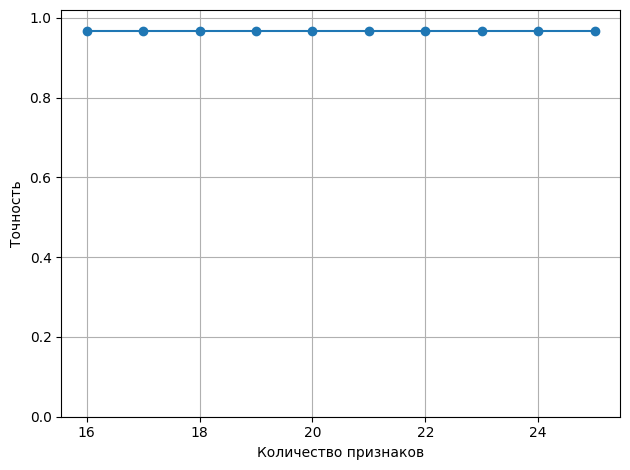

In [104]:
lr = LogisticRegression(random_state=1, C=0.001, max_iter=100, penalty='l1', solver='liblinear')
sbs_lr = the_best_features(lr, k_features=16, scoring=f1_scorer_micro, X_train=X_train_pca, y_train=y_train_reset)

In [106]:
X_train_pca_sbs, X_test_pca_sbs = select_index_features(sbs_lr, index=1, X_train=X_train_pca, X_test=X_test_pca)

In [107]:
lr = model_training(lr, X_train=X_train_pca_sbs, y_train=y_train_reset, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.548
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.357
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.571
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.524
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.476
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.500
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.429
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.524
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.571
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.381
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.500
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.643
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.512
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.610
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.634
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.488
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.488
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.439
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.610
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.488
Точность по CV: 0.515 +/- 0.076


In [108]:
data = {"Train": (X_train_pca_sbs, y_train_reset),
        "Test": (X_test_pca_sbs, y_test_reset)}

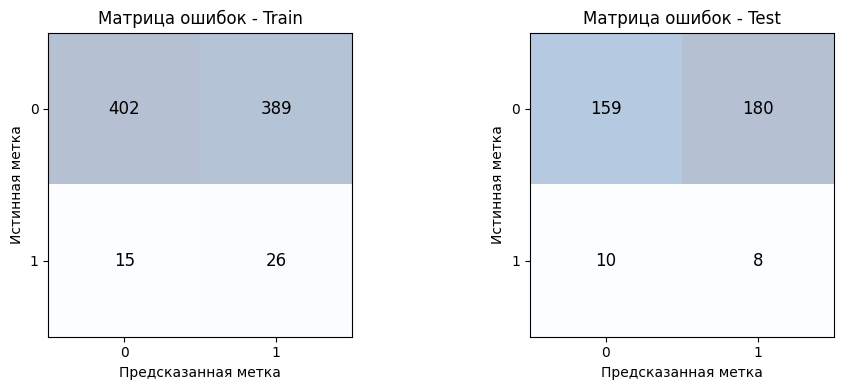

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+--------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |    MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+========+
|   Train   |      0.514 |               0.514 |               0.513 |            0.514 |            0.571 |        0.514 |        0.39  |  0.062 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+--------+
|   Test    |      0.468 |               0.468 |               0.492 |            0.468 |            0.457 |        0.468 |        0.352 | -0.038 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----

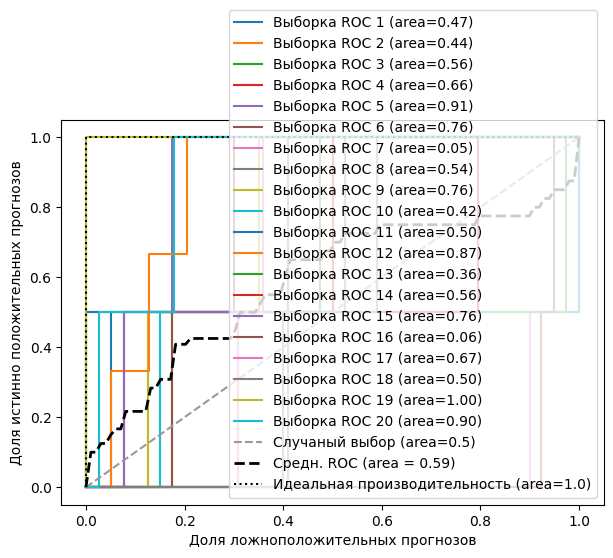

In [109]:
results = evalute_model(lr, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(lr, X_train_pca_sbs, X_test_pca_sbs, y_train_reset, y_test_reset, n_splits=20)

### Алгоритм k-ближайших соседей

In [110]:
knn = KNeighborsClassifier(metric='minkowski')
param_grid_knn = {
    'n_neighbors': list(range(1, 7, 2)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2, 3], 
    'leaf_size': [10, 20, 30, 40, 50]
}
grid_search_for_model(knn, param_grid_knn, X_train_pca, y_train_reset)

Fitting 20 folds for each of 270 candidates, totalling 5400 fits
0.15
{'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}


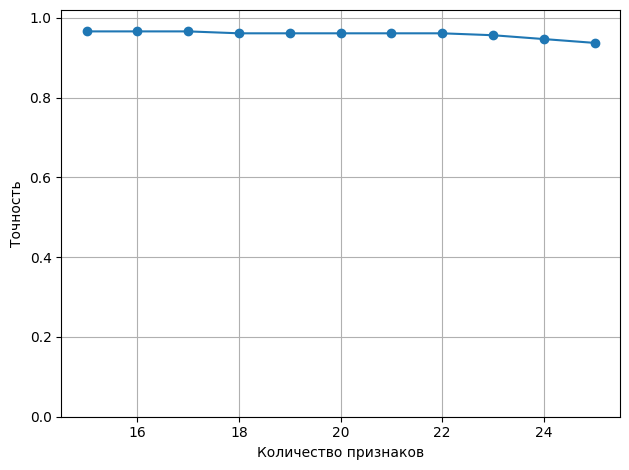

In [111]:
knn = KNeighborsClassifier(metric='minkowski', algorithm = 'auto', leaf_size = 10, n_neighbors = 1, p = 1, weights = 'uniform')
sbs_knn = the_best_features(knn, k_features=15, scoring=f1_scorer_micro, X_train=X_train_pca, y_train=y_train_reset)

In [112]:
X_train_pca_sbs, X_test_pca_sbs = select_index_features(sbs_knn, index=-1, X_train=X_train_pca, X_test=X_test_pca)

In [113]:
knn = KNeighborsClassifier(metric='minkowski', algorithm = 'auto', leaf_size = 10, n_neighbors = 1, p = 3, weights= 'uniform')
knn = model_training(knn, X_train=X_train_pca_sbs, y_train=y_train_reset, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.857
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.881
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.857
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.929
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.927
Точность по CV: 0.928 +/- 0.031


In [114]:
data = {"Train": (X_train_pca_sbs, y_train)_reset,
        "Test": (X_test_pca_sbs, y_test_reset}

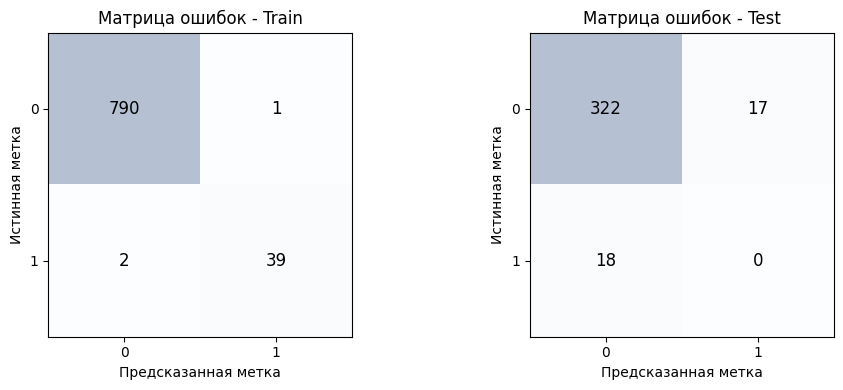

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+--------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |    MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+========+
|   Train   |      0.996 |               0.996 |               0.986 |            0.996 |            0.975 |        0.996 |        0.981 |  0.961 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+--------+
|   Test    |      0.902 |               0.902 |               0.474 |            0.902 |            0.475 |        0.902 |        0.474 | -0.052 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----

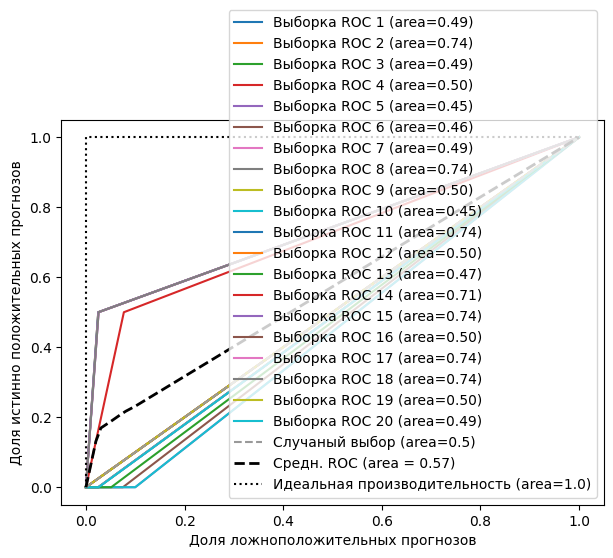

In [115]:
results = evalute_model(knn, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve(knn, X_train_pca_sbs, X_test_pca_sbs, y_train_reset, y_test_reset, n_splits=20)

### SVM

In [ ]:
svc = SVC(random_state=1)
param_grid_svc = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'coef0': [0, 1, 2]  
    }
]
grid_search_for_model(svc, param_grid_svc, X_train_pca, y_train_reset)

### MLP

In [69]:
X_val, X_test, y_val, y_test_val = train_test_split(
   X_test_pca, y_test, test_size=0.5, random_state=42, stratify=y_test_reset
)

In [70]:
smote = SMOTE(random_state=42, sampling_strategy=0.55)
X_train_sample, y_train_sample = smote.fit_resample(X_train_pca, y_train_reset)

In [46]:
param_grid_net = {
    'batch_size': [16, 32],
    'epochs': [30],
    'learning_rate': [0.001],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'elu'],
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'dropout_rate': [0.2],
    'use_batch_norm': [True],
    'l1_reg': [0.001],
    'l2_reg': [0.001]
}

best_score, best_params, all_results = manual_keras_grid_search(
    X_train_pca, y_train_reset, param_grid_net, cv=5
)

Всего комбинаций: 24

Комбинация 1/24: {'activation': 'relu', 'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 30, 'hidden_layer_sizes': (16, 8), 'l1_reg': 0.001, 'l2_reg': 0.001, 'learning_rate': 0.001, 'optimizer': 'adam', 'use_batch_norm': True}
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
  Fold 1: recall = 0.0000
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
  Fold 2: recall = 0.1000
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
  Fold 3: recall = 0.0000
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
  Fold 4: recall = 0.0000
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
  Fold 5: recall = 0.0000
  Средний recall: 0.0

In [37]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train_sample.shape[1], )))

model.add(layers.Dense(64, 
                      activation='relu',
                      kernel_regularizer=regularizers.l2(0.0001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l2(0.0001)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(16, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=40, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/40
41
411m 1/41 ━━━━━━━━━━━━━━━━━━━━ 4:53 7s/step - accuracy: 0.4062 - loss: 1.5899 - precision: 0.3529 - recall: 0.4286
411m 5/41 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4547 - loss: 1.1813 - precision: 0.4044 - recall: 0.4875
411m 7/41 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4547 - loss: 1.1320 - precision: 0.3971 - recall: 0.4912
411m 9/41 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4558 - loss: 1.1029 - precision: 0.3912 - recall: 0.4907
411m11/41 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4536 - loss: 1.0852 - precision: 0.3814 - recall: 0.4841
411m15/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4511 - loss: 1.0644 - precision: 0.3745 - recall: 0.4789
411m19/41 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4512 - loss: 1.0511 - precision: 0.3731 - recall: 0.4781
411m26/41 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4499 - loss: 1.0383 - precision: 0.3669 - recall: 0.4738
411m32/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4499 - l

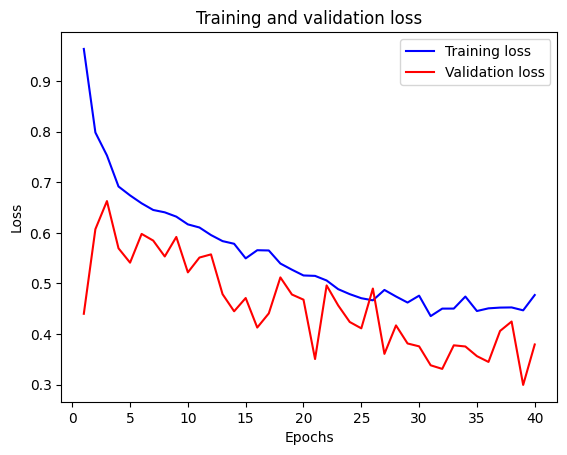

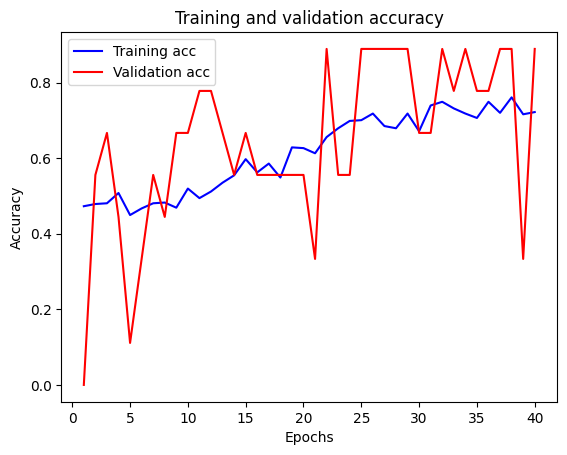

<Figure size 640x480 with 0 Axes>

In [38]:
history_dict = history.history
epochs = range(1, 41)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training acc')
plt.plot(epochs, val_acc_values, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.clf()

In [39]:
data = {
            "Train": (X_train_pca, y_train_reset),
            "Validation": (X_val, y_val_reset),
            "Test": (X_test, y_test_val)
        }

26
261m 1/26 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step
261m16/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


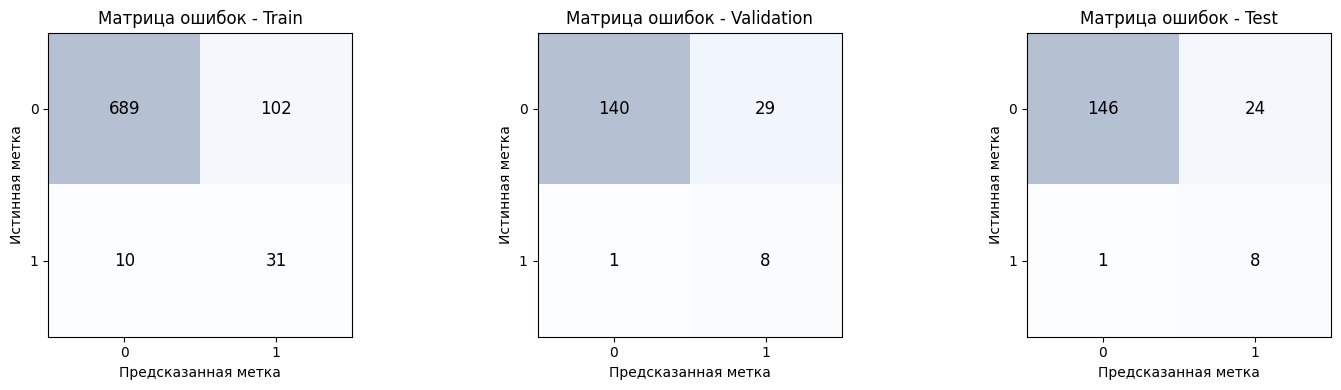

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.865 |               0.865 |               0.609 |            0.865 |            0.814 |        0.865 |        0.641 | 0.37  |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.831 |               0.831 |               0.605 |            0.831 |            0.859 |        0.831 |        0.626 | 0.387 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

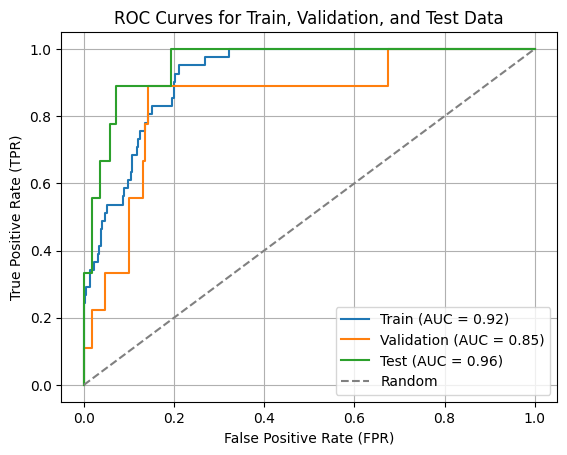

In [40]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'],
                        average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)

In [41]:
model.save('model_KEEEvers_binary_classification_recall_best.keras')

In [84]:
import joblib
import json
joblib.dump(preprocessor, 'preprocessor_kee_evers_final_two.pkl')
joblib.dump(pca, 'pca_kee_evers_final_three.pkl')
model.save('neural_net_model_kee_evers_final_three.keras')
metadata = {
    'model_type': type(model).__name__,
    'model_config': model.get_config(),
    'optimizer_config': model.optimizer.get_config(),
}
with open('metadata_kee_evers_pca_binary_final_two.json', 'w') as f:
    json.dump(metadata, f, indent=4)

## Уменьшение размерности с помощью алгоритма отбора признаков и обучение различных типов моделей

In [123]:
numeric_features = ['age', 'occlusion_time']
scaler = StandardScaler()
scaler.fit(X_train[numeric_features])
X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [124]:
X_train

,gender_Ж,gender_М,gender_ж,gender_м,gender_м,degree_of_stenosis_of_the_internal_carotid_artery_ 70-89,degree_of_stenosis_of_the_internal_carotid_artery_0-49,degree_of_stenosis_of_the_internal_carotid_artery_50-69,degree_of_stenosis_of_the_internal_carotid_artery_70-89,degree_of_stenosis_of_the_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_0-49,stenosis_degree_of_the_contralateral_internal_carotid_artery_100,stenosis_degree_of_the_contralateral_internal_carotid_artery_50-69,stenosis_degree_of_the_contralateral_internal_carotid_artery_70-89,stenosis_degree_of_the_contralateral_internal_carotid_artery_90-99,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п КЭЭ,stenosis_degree_of_the_contralateral_internal_carotid_artery_с/п ТБА,calcinosis_0,calcinosis_1,calcinosis_2,pivsa_0,pivsa_1,symptoms_of_internal_carotid_artery_stenosis_0,symptoms_of_internal_carotid_artery_stenosis_1,hsmn_0,hsmn_1,hsmn_2,hsmn_3,hsmn_4,angina_pectoris_FC_0,angina_pectoris_FC_1,angina_pectoris_FC_2,angina_pectoris_FC_3,pim_0,pim_1,heart_rhythm_disturbances_0,heart_rhythm_disturbances_1,hsn_0,hsn_1,hsn_2 а,hsn_2 б,hsn_3,FC_by_NYHA_0,FC_by_NYHA_1,FC_by_NYHA_2,FC_by_NYHA_3,FC_by_NYHA_4,sd_0,sd_1,hobl_0,hobl_1,hobl_2,hobl_3,history_of_oncological_cancer_0,history_of_oncological_cancer_1,history_of_oncological_cancer_2,history_of_oncological_cancer_3,age,occlusion_time
867,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0.684310,-0.196316
155,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,-0.575305,0.293200
410,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1.188156,-0.196316
608,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1.817963,1.435404
923,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0.558348,0.130028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,-1.708958,-0.359489
408,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,-2.086842,-1.338521
394,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,-2.716649,-1.012177
810,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,-0.197420,0.130028


In [125]:
X_train = X_train.reset_index()
X_test = X_test.reset_index()
y_train = y_train.reset_index()
y_test = y_test.reset_index()

In [126]:
del X_train['index']
del X_test['index']
del y_train['index']
del y_test['index']
y_test

,complication
0,0
1,1
2,0
3,0
4,0
...,...
352,0
353,0
354,0
355,0


In [127]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

### Логистическая регрессия

In [41]:
lr = LogisticRegression(random_state=1)
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_grid_lr = [{'C': param_range, 'solver': ['lbfgs'], 'penalty': ['l2'], 'max_iter': [1000, 2000, 5000, 1000] }, 
             {'C': param_range, 'solver': ['liblinear'], 'penalty': ['l2', 'l1'], 'max_iter': [100, 200, 5000, 1000] }, 
             {'C': param_range, 'solver': ['newton-cg'], 'penalty': ['l2']},
             {'C': param_range, 'solver': ['newton-cholesky'], 'penalty': ['l2'], 'max_iter': [100, 200, 500, 1000] },
             {'C': param_range, 'solver': ['sag'], 'penalty': ['l2'], 'max_iter': [5000, 10000] },
             {'C': param_range, 'solver': ['saga'], 'penalty': ['elasticnet'], 'max_iter': [5000, 10000], 'l1_ratio': [0.1, 0.2, 0.5, 0.9]},
            {'C': param_range, 'solver': ['saga'], 'penalty': ['l1', 'l2'], 'max_iter': [5000, 10000]}
             ]
halving_search_for_model(lr, param_grid_lr, X_train, y_train) 

n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 50
max_resources_: 832
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 186
n_resources: 50
Fitting 5 folds for each of 186 candidates, totalling 930 fits
----------
iter: 1
n_candidates: 62
n_resources: 150
Fitting 5 folds for each of 62 candidates, totalling 310 fits
----------
iter: 2
n_candidates: 21
n_resources: 450
Fitting 5 folds for each of 21 candidates, totalling 105 fits
0.37523809523809526
{'C': 100.0, 'l1_ratio': 0.1, 'max_iter': 10000, 'penalty': 'elasticnet', 'solver': 'saga'}


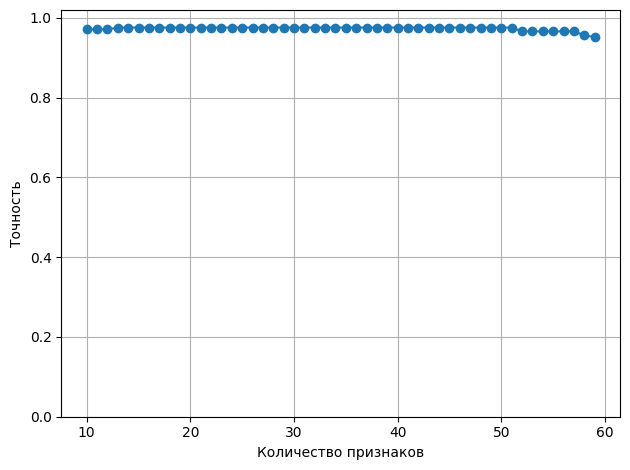

In [42]:
lr = LogisticRegression(random_state=1, C=100.0, max_iter=10000, penalty='elasticnet', solver='saga', l1_ratio=0.1)
sbs_lr = the_best_features(lr, k_features=10, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [47]:
X_train_sbs, X_test_sbs = select_index_features_for_df(sbs_lr, index=3, X_train=X_train, X_test=X_test)

In [49]:
lr = model_training_for_df(lr, X_train=X_train_sbs, y_train=y_train, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.905
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.976
Точность по CV: 0.946 +/- 0.020


In [50]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}

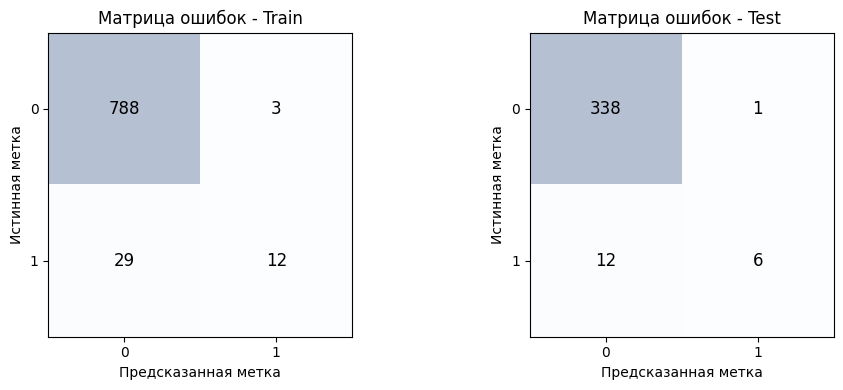

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.962 |               0.962 |               0.882 |            0.962 |            0.644 |        0.962 |        0.704 | 0.47  |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.964 |               0.964 |               0.911 |            0.964 |            0.665 |        0.964 |        0.731 | 0.521 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

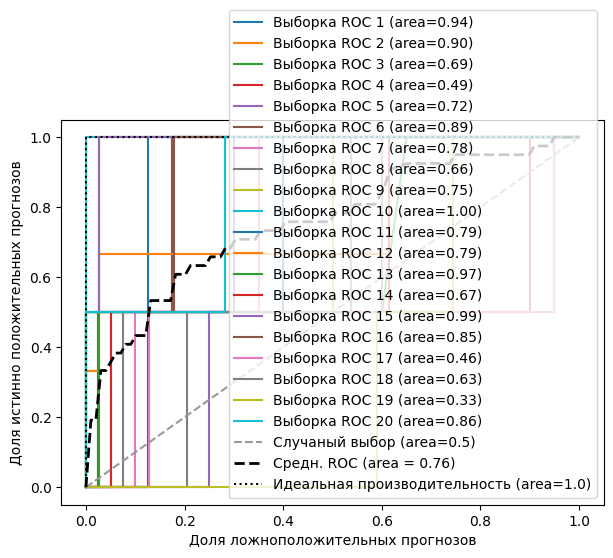

In [55]:
results = evalute_model(lr, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_df(lr, X_train_sbs, X_test_sbs, y_train, y_test, n_splits=20)

### Алгоритм k-ближайших соседей

In [62]:
knn = KNeighborsClassifier(metric='minkowski')
param_grid_knn = {
    'n_neighbors': list(range(1, 7, 2)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2, 3], 
    'leaf_size': [10, 20, 30, 40, 50]
}
halving_search_for_model(knn, param_grid_knn, X_train, y_train)

n_iterations: 3
n_required_iterations: 6
n_possible_iterations: 3
min_resources_: 50
max_resources_: 832
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 270
n_resources: 50
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
----------
iter: 1
n_candidates: 90
n_resources: 150
Fitting 5 folds for each of 90 candidates, totalling 450 fits
----------
iter: 2
n_candidates: 30
n_resources: 450
Fitting 5 folds for each of 30 candidates, totalling 150 fits
0.18857142857142858
{'algorithm': 'kd_tree', 'leaf_size': 10, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}


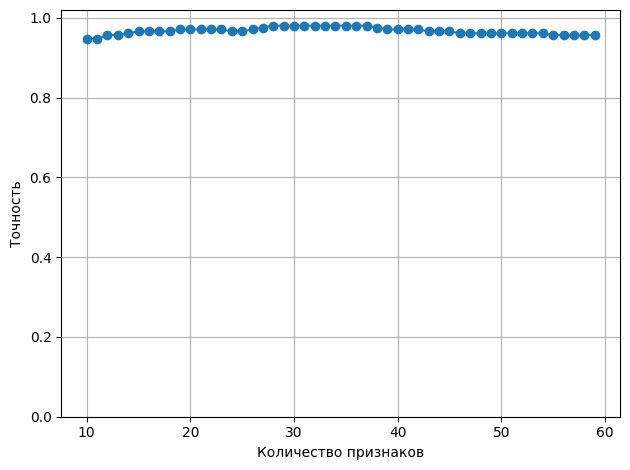

In [63]:
knn = KNeighborsClassifier(metric='minkowski', algorithm = 'kd_tree', leaf_size = 10, n_neighbors = 1, p = 3, weights = 'uniform')
sbs_knn = the_best_features(knn, k_features=10, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [64]:
X_train_sbs, X_test_sbs = select_index_features_for_df(sbs_knn, index=27, X_train=X_train, X_test=X_test)

In [65]:
knn = model_training_for_df(knn, X_train=X_train_sbs, y_train=y_train, n_splits=20, cv=20)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.929
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.927
Точность по CV: 0.946 +/- 0.021


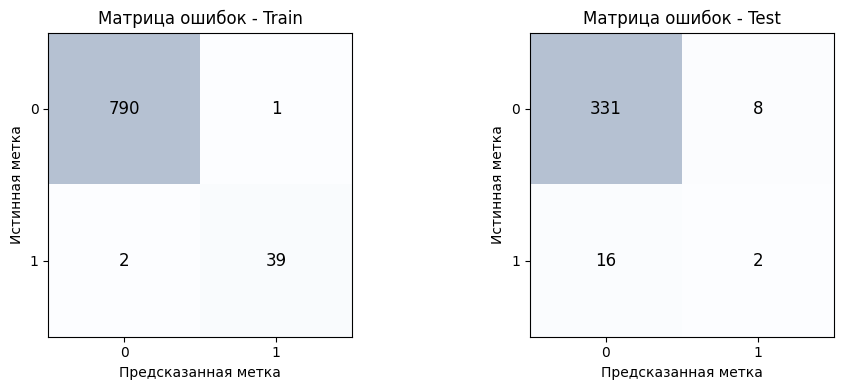

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.996 |               0.996 |               0.986 |            0.996 |            0.975 |        0.996 |        0.981 | 0.961 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.933 |               0.933 |               0.577 |            0.933 |            0.544 |        0.933 |        0.554 | 0.116 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

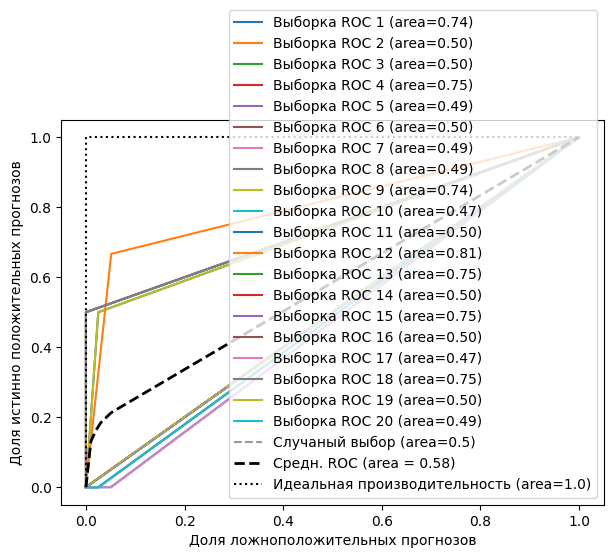

In [66]:
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evalute_model(knn, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_df(knn, X_train_sbs, X_test_sbs, y_train, y_test, n_splits=20)

In [67]:
svc = SVC(random_state=1)
param_grid_svc = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'kernel': ['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'coef0': [0, 1, 2]  
    }
]
halving_search_for_model(svc, param_grid_svc, X_train, y_train)

n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 50
max_resources_: 832
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 128
n_resources: 50
Fitting 5 folds for each of 128 candidates, totalling 640 fits
----------
iter: 1
n_candidates: 43
n_resources: 150
Fitting 5 folds for each of 43 candidates, totalling 215 fits
----------
iter: 2
n_candidates: 15
n_resources: 450
Fitting 5 folds for each of 15 candidates, totalling 75 fits
0.36380952380952386
{'C': 100, 'coef0': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}


### SVM

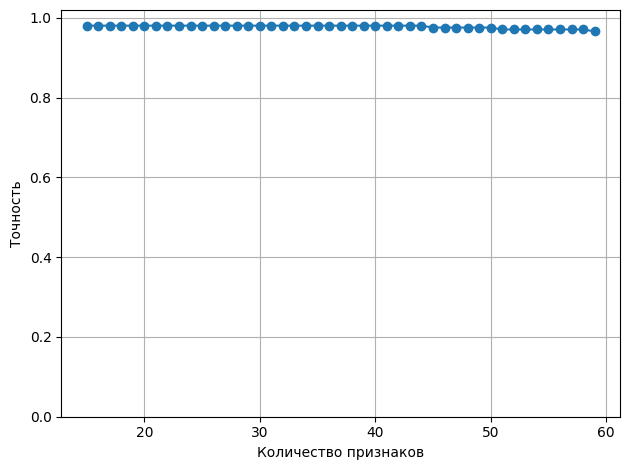

In [68]:
svc = SVC(kernel='poly', gamma='scale', C=100, coef0=2, degree=2, probability=True)
sbs_svc = the_best_features(SVC(kernel='poly', gamma='auto', C=100, coef0=1, degree=2), k_features=15, 
                            scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [69]:
X_train_sbs, X_test_sbs = select_index_features_for_df(sbs_svc, index=4, X_train=X_train, X_test=X_test)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.881
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.905
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.878
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.878
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.902
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.951
Точность по CV: 0.918 +/- 0.027


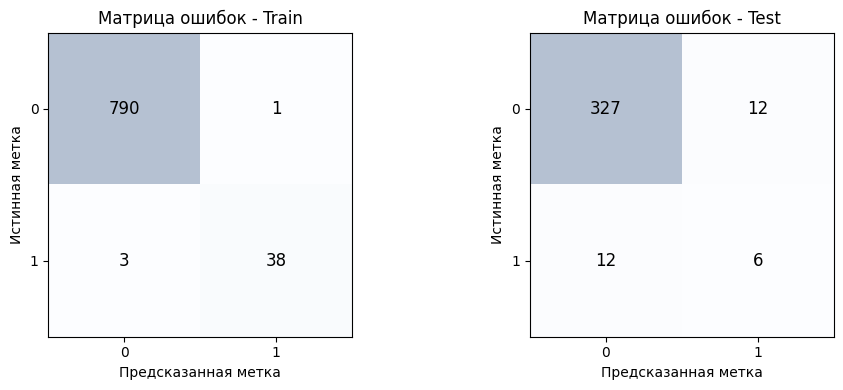

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.995 |               0.995 |               0.985 |            0.995 |            0.963 |        0.995 |        0.974 | 0.948 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.933 |               0.933 |               0.649 |            0.933 |            0.649 |        0.933 |        0.649 | 0.298 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

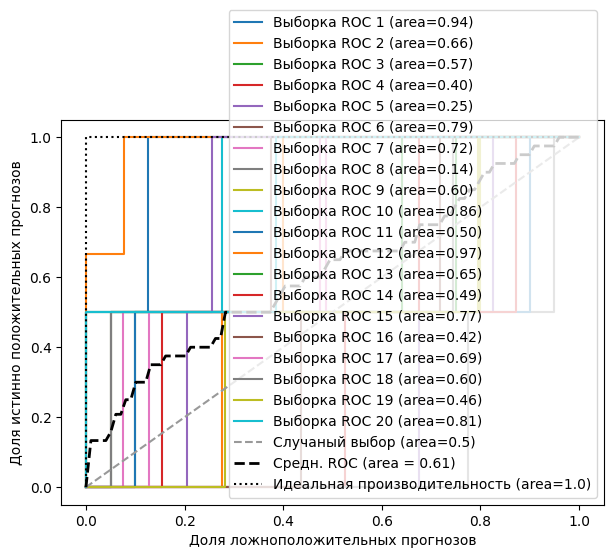

In [73]:
svc = model_training_for_df(svc, X_train=X_train_sbs, y_train=y_train, n_splits=20, cv=20)
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evalute_model(svc, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_df(svc, X_train_sbs, X_test_sbs, y_train, y_test, n_splits=20)

### Random Forest

In [74]:
forest = RandomForestClassifier(random_state=1, n_jobs=-1)
param_grid_forest = {
    'n_estimators': [50, 100, 150], 
    'max_depth': [None, 5, 10, 15], 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None],
    'bootstrap': [True, False] 
}
halving_search_for_model(forest, param_grid_forest, X_train, y_train)

n_iterations: 3
n_required_iterations: 7
n_possible_iterations: 3
min_resources_: 50
max_resources_: 832
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 864
n_resources: 50
Fitting 5 folds for each of 864 candidates, totalling 4320 fits
----------
iter: 1
n_candidates: 288
n_resources: 150
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
----------
iter: 2
n_candidates: 96
n_resources: 450
Fitting 5 folds for each of 96 candidates, totalling 480 fits
0.36380952380952386
{'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


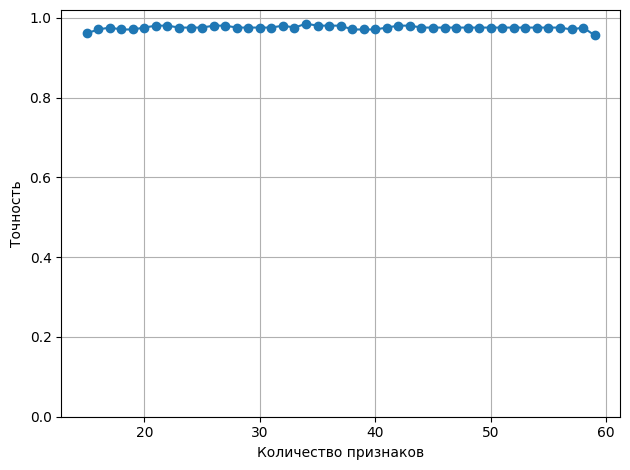

In [75]:
forest = RandomForestClassifier(n_estimators=100, min_samples_split=10, min_samples_leaf=2,
                                        max_features='sqrt', max_depth=15, class_weight='balanced',bootstrap=False)
sbs_forest = the_best_features(forest, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [77]:
X_train_sbs, X_test_sbs = select_index_features_for_df(sbs_forest, index=20, X_train=X_train, X_test=X_test)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.905
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.857
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.976
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.976
Точность по CV: 0.948 +/- 0.020


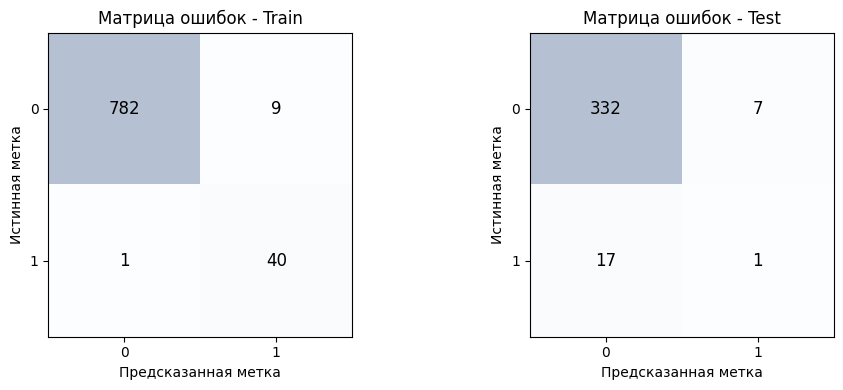

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.988 |               0.988 |               0.908 |            0.988 |            0.982 |        0.988 |        0.941 | 0.887 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.933 |               0.933 |               0.538 |            0.933 |            0.517 |        0.933 |        0.521 | 0.052 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

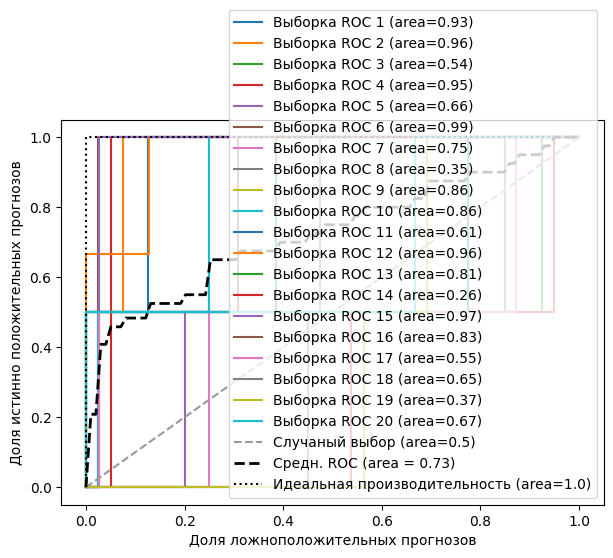

In [80]:
forest = model_training_for_df(forest, X_train=X_train_sbs, y_train=y_train, n_splits=20, cv=20)
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evalute_model(forest, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_df(forest, X_train_sbs, X_test_sbs, y_train, y_test, n_splits=20)

### AdaBoost

In [81]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=1)
ada  = AdaBoostClassifier(estimator=tree, random_state=1)
param_grid_ada = {
    'n_estimators': [400, 500, 600, 700, 800],
    'learning_rate': [0.01, 0.03, 0.1, 0.3, 1.0],
    'estimator__max_depth': [1, 2, 3, 4, 5]
}

halving_search_for_model(ada, param_grid_ada, X_train, y_train)

n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 50
max_resources_: 832
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 125
n_resources: 50
Fitting 5 folds for each of 125 candidates, totalling 625 fits
----------
iter: 1
n_candidates: 42
n_resources: 150
Fitting 5 folds for each of 42 candidates, totalling 210 fits
----------
iter: 2
n_candidates: 14
n_resources: 450
Fitting 5 folds for each of 14 candidates, totalling 70 fits
0.14857142857142858
{'estimator__max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 500}


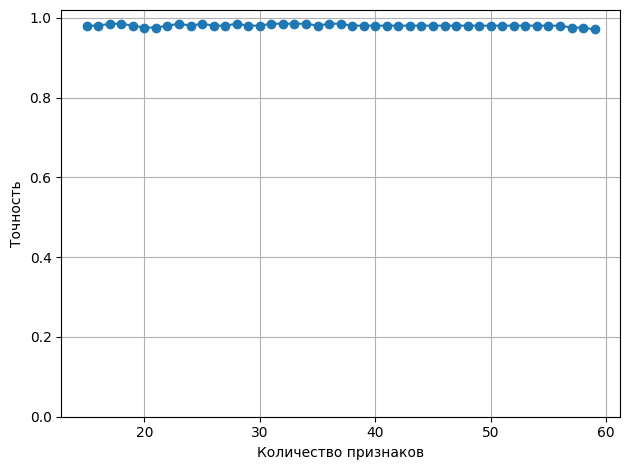

In [83]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=5), 
                         n_estimators=500, learning_rate=0.1, random_state=1)
sbs_ada = the_best_features(ada, k_features=15, scoring=f1_scorer_micro, X_train=X_train, y_train=y_train)

In [84]:
X_train_sbs, X_test_sbs = select_index_features_for_df(sbs_forest, index=3, X_train=X_train, X_test=X_test)

Выборка: 01, Распр. кл.: [40  2], Точн.: 0.929
Выборка: 02, Распр. кл.: [40  2], Точн.: 0.976
Выборка: 03, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 04, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 05, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 06, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 07, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 08, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 09, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 10, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 11, Распр. кл.: [40  2], Точн.: 0.952
Выборка: 12, Распр. кл.: [39  3], Точн.: 0.952
Выборка: 13, Распр. кл.: [39  2], Точн.: 0.976
Выборка: 14, Распр. кл.: [39  2], Точн.: 0.927
Выборка: 15, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 16, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 17, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 18, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 19, Распр. кл.: [39  2], Точн.: 0.951
Выборка: 20, Распр. кл.: [39  2], Точн.: 0.976
Точность по CV: 0.953 +/- 0.012


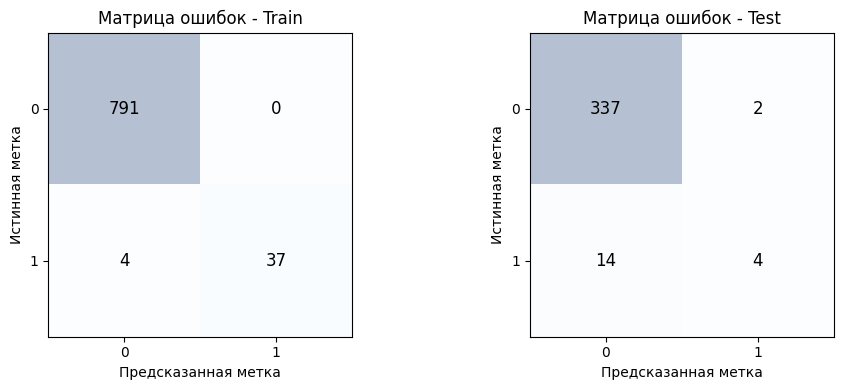

+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset  |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+===========+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train   |      0.995 |               0.995 |               0.997 |            0.995 |            0.951 |        0.995 |        0.973 | 0.948 |
+-----------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|   Test    |      0.955 |               0.955 |               0.813 |            0.955 |            0.608 |        0.955 |        0.655 | 0.368 |
+-----------+------------+---------------------+---------------------+------------------+------------------+----------

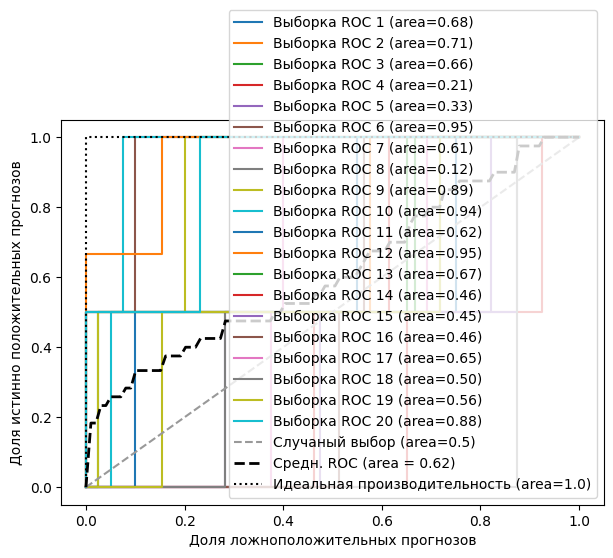

In [85]:
ada = model_training_for_df(ada, X_train=X_train_sbs, y_train=y_train, n_splits=20, cv=20)
data = {"Train": (X_train_sbs, y_train),
        "Test": (X_test_sbs, y_test)}
results = evalute_model(ada, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_df(ada, X_train_sbs, X_test_sbs, y_train, y_test, n_splits=20)

### MLP

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)
numeric_features = ['age', 'occlusion_time']
scaler = StandardScaler()
scaler.fit(X_train[numeric_features])
X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
X_train = X_train.reset_index()
X_test = X_test.reset_index()
y_train = y_train.reset_index()
y_test = y_test.reset_index()
del X_train['index']
del X_test['index']
del y_train['index']
del y_test['index']
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [158]:
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)
smote = SMOTE(random_state=42, sampling_strategy=0.75)
X_train_sample, y_train_sample = smote.fit_resample(X_train, y_train)

In [164]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train.shape[1], )))

model.add(layers.Dense(32, 
                      activation='relu',
                      kernel_regularizer=regularizers.l1_l2(0.01)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))


model.add(layers.Dense(8, activation='relu'),)
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(6, activation='elu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall', 'precision'], 
)
history = model.fit(X_train_sample, y_train_sample, epochs=50, batch_size=16, validation_data=(X_val, y_val))

Epoch 1/50
87
871m 1/87 ━━━━━━━━━━━━━━━━━━━━ 8:40 6s/step - accuracy: 0.5000 - loss: 3.4367 - precision: 0.6250 - recall: 0.5000
871m 8/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5152 - loss: 3.3512 - precision: 0.4900 - recall: 0.4951 
871m15/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5347 - loss: 3.2879 - precision: 0.4872 - recall: 0.5156
871m24/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5412 - loss: 3.2384 - precision: 0.4802 - recall: 0.5166
871m33/87 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5456 - loss: 3.2040 - precision: 0.4804 - recall: 0.5142
871m40/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5489 - loss: 3.1811 - precision: 0.4806 - recall: 0.5153
871m49/87 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5541 - loss: 3.1542 - precision: 0.4839 - recall: 0.5215
871m56/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5585 - loss: 3.1338 - precision: 0.4875 - recall: 0.5272
871m61/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5618 - loss: 3.

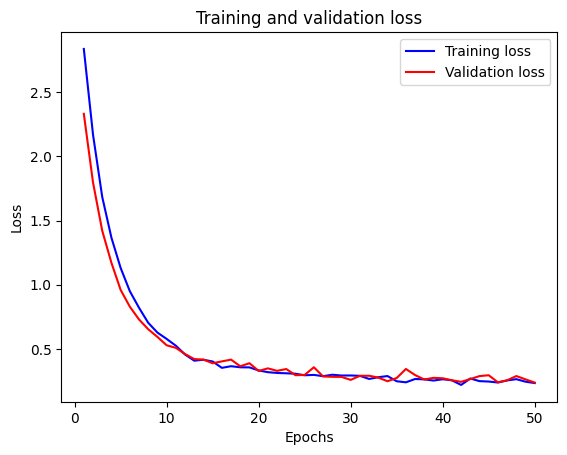

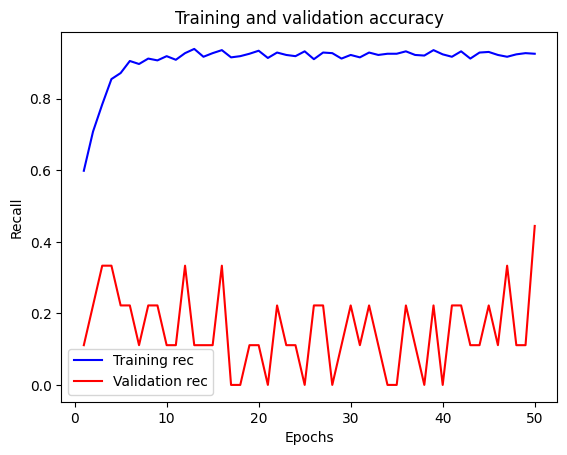

<Figure size 640x480 with 0 Axes>

In [165]:
history_dict = history.history
epochs = range(1, 51)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

plt.plot(epochs, loss_values, 'b', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()
acc_values = history_dict['recall']
val_acc_values = history_dict['val_recall']

plt.plot(epochs, acc_values, 'b', label='Training rec')
plt.plot(epochs, val_acc_values, 'r', label='Validation rec')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()
plt.clf()

In [166]:
data = {
            "Train": (X_train, y_train),
            "Validation": (X_val, y_val),
            "Test": (X_test, y_test)
        }

26
261m 1/26 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step
261m21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
66/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6
61/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


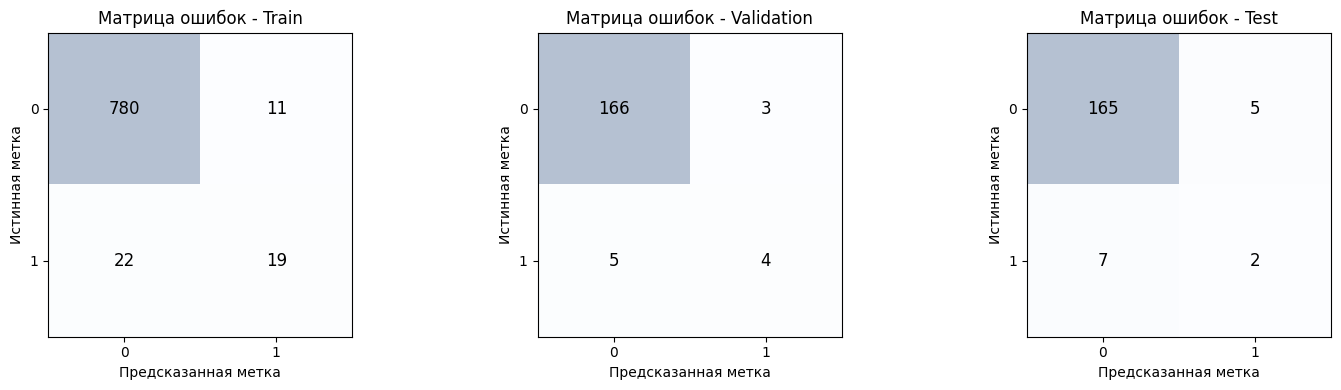

+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
|  Dataset   |   Accuracy |   Precision (micro) |   Precision (macro) |   Recall (micro) |   Recall (macro) |   F1 (micro) |   F1 (macro) |   MCC |
+============+============+=====================+=====================+==================+==================+==============+==============+=======+
|   Train    |      0.96  |               0.96  |               0.803 |            0.96  |            0.725 |        0.96  |        0.757 | 0.522 |
+------------+------------+---------------------+---------------------+------------------+------------------+--------------+--------------+-------+
| Validation |      0.955 |               0.955 |               0.771 |            0.955 |            0.713 |        0.955 |        0.738 | 0.481 |
+------------+------------+---------------------+---------------------+------------------+------------------+---

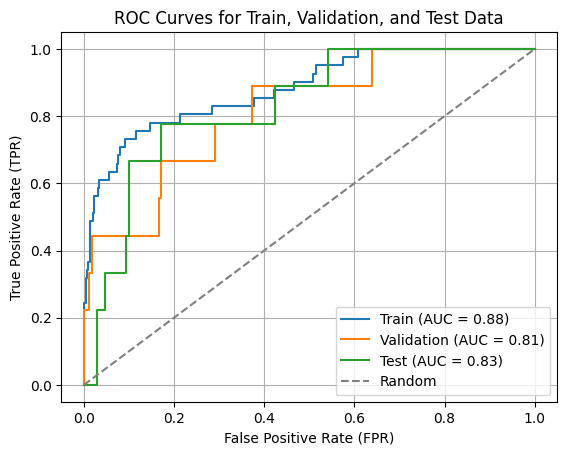

In [167]:
results = evalute_model(model, data, metrics=['accuracy', 'precision', 'recall', 'f1', 'mcc'], average_methods=['micro', 'macro'])
ROC_curve_for_keras(data, model)